# Unit12 Example 01 - 晶圓製程最佳光阻劑膜厚

本 Notebook 以**晶圓製程中光阻劑膜厚最適化**為例，示範如何使用 `scipy.optimize.minimize_scalar()` 求解單變數有界最適化問題，並與黃金分割法（Golden Section Search）比較，最後進行敏感度分析。

## 目標
- 建立缺損率、良率與產量數學模型，推導完好晶片產量目標函數
- 使用 `minimize_scalar(method='bounded')` 求解最佳光阻劑膜厚
- 以 Python 實作黃金分割法，與 SciPy 結果比較
- 繪製目標函數曲線圖，標示最佳點位置
- 進行敏感度分析：探討參數 $\beta$ 和 $a$ 變化對最佳膜厚與產量的影響

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize_scalar

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與數學模型

**問題背景：** 在晶圓製程中，光阻劑膜厚 $d$ 同時影響缺損率與生產速率。試決定使每小時完好晶片產量最多之最佳膜厚 $d^*$。

#### 數學模型

| 模型 | 方程式 | 說明 |
|------|--------|------|
| 缺損密度 | $D_0 = 1.5\, d^{-3}$ | 膜薄則缺損多 |
| 良率 | $\eta = \left(1 + \beta D_0 a\right)^{-4}$ | Bose-Einstein 複合缺損模型 |
| 產量 | $V = 125 - 50d + 5d^2$ (wafers/h) | 膜厚增加，塗佈時間增加，產量下降 |
| 目標函數 | $\max f(d) = 100\, V(d)\, \eta(d)$ | 等價於 $\min [-f(d)]$ |

**預設參數：** $\beta = 1.0$，$a = 0.5\ \text{cm}^2$，求解區間 $d \in [0.5,\ 2.5]$ μm

In [3]:
# ========================================
# 製程參數設定
# ========================================
BETA = 1.0   # 製程工藝因子（無因次）
A    = 0.5   # 晶片面積（cm²）

# ========================================
# 數學模型函數定義
# ========================================
def defect_density(d):
    """缺損密度模型：D0 = 1.5 * d^(-3)"""
    return 1.5 * d**(-3)

def yield_fraction(d, beta=BETA, a=A):
    """良率模型：eta = 1 / (1 + beta * D0 * a)^4"""
    D0 = defect_density(d)
    return 1.0 / (1.0 + beta * D0 * a)**4

def throughput(d):
    """產量模型：V = 125 - 50*d + 5*d^2  (wafers/h)"""
    return 125 - 50 * d + 5 * d**2

def good_wafers(d, beta=BETA, a=A):
    """每小時完好晶片產量：f = 100 * V * eta"""
    return 100 * throughput(d) * yield_fraction(d, beta, a)

def objective(d, beta=BETA, a=A):
    """最小化目標函數：-f(d)"""
    return -good_wafers(d, beta, a)

# 驗證：列印在幾個測試點的函數值
print("=" * 55)
print(f"{'膜厚 d (μm)':>12} {'D0':>10} {'η (%)':>10} {'V (w/h)':>10} {'f (w/h)':>10}")
print("-" * 55)
for d_test in [0.5, 1.0, 1.5, 2.0, 2.5]:
    D0_v = defect_density(d_test)
    eta_v = yield_fraction(d_test) * 100
    V_v   = throughput(d_test)
    f_v   = good_wafers(d_test)
    print(f"{d_test:>12.2f} {D0_v:>10.4f} {eta_v:>10.2f} {V_v:>10.2f} {f_v:>10.2f}")
print("=" * 55)

   膜厚 d (μm)         D0      η (%)    V (w/h)    f (w/h)
-------------------------------------------------------
        0.50    12.0000       0.04     101.25       4.22
        1.00     1.5000      10.66      80.00     852.98
        1.50     0.4444      44.81      61.25    2744.77
        2.00     0.1875      69.88      45.00    3144.42
        2.50     0.0960      82.90      31.25    2590.63


---
### 3. 目標函數曲線圖

繪製 $f(d)$（每小時完好晶片產量）隨膜厚 $d$ 的變化曲線，初步觀察最大值位置與函數形狀。

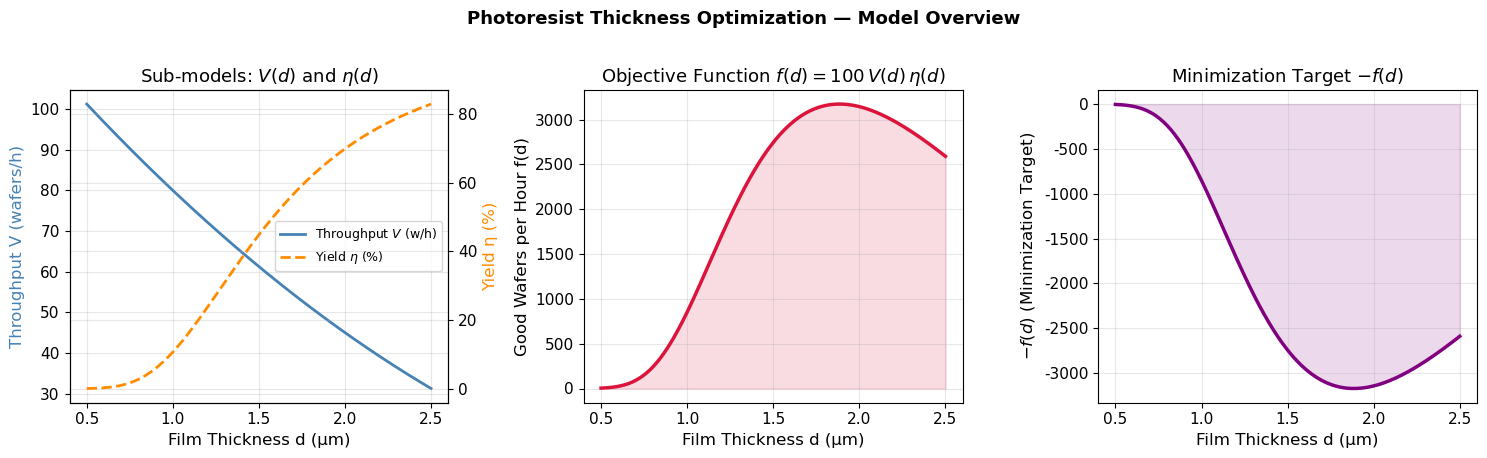

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs\fig_01_model_overview.png


In [4]:
# ========================================
# 繪製目標函數曲線（預覽用，最佳點於下一節求得後標示）
# ========================================
d_range = np.linspace(0.5, 2.5, 300)
f_vals  = good_wafers(d_range)
V_vals  = throughput(d_range)
eta_vals = yield_fraction(d_range) * 100  # 轉換為百分比

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 子圖 1：各子模型
ax = axes[0]
ax.plot(d_range, V_vals, color='steelblue', label='Throughput $V$ (w/h)')
ax2 = ax.twinx()
ax2.plot(d_range, eta_vals, color='darkorange', linestyle='--', label='Yield $\\eta$ (%)')
ax.set_xlabel('Film Thickness d (μm)')
ax.set_ylabel('Throughput V (wafers/h)', color='steelblue')
ax2.set_ylabel('Yield η (%)', color='darkorange')
ax.set_title('Sub-models: $V(d)$ and $\\eta(d)$')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)

# 子圖 2：目標函數 f(d) = 100 * V * η
ax = axes[1]
ax.plot(d_range, f_vals, color='crimson', linewidth=2.5)
ax.set_xlabel('Film Thickness d (μm)')
ax.set_ylabel('Good Wafers per Hour f(d)')
ax.set_title('Objective Function $f(d) = 100\\,V(d)\\,\\eta(d)$')
ax.fill_between(d_range, f_vals, alpha=0.15, color='crimson')

# 子圖 3：最小化目標 -f(d)
ax = axes[2]
ax.plot(d_range, -f_vals, color='purple', linewidth=2.5)
ax.set_xlabel('Film Thickness d (μm)')
ax.set_ylabel('$-f(d)$ (Minimization Target)')
ax.set_title('Minimization Target $-f(d)$')
ax.fill_between(d_range, -f_vals, alpha=0.15, color='purple')

plt.suptitle('Photoresist Thickness Optimization — Model Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / 'fig_01_model_overview.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔已儲存：{fig_path}")

---
### 4. `scipy.optimize.minimize_scalar()` 求解

使用 `method='bounded'`（Brent 法）在區間 $[0.5,\ 2.5]$ 內搜尋最小化目標 $-f(d)$，等價於找使完好晶片產量最大的膜厚。

  minimize_scalar (Brent's Method) 求解結果
  收斂狀態  : 成功 ✓
  函數評估次: 10
  最佳膜厚 d*  = 1.884325 μm
  最大產量 f*  = 3173.2456 wafers/h
    ├ 缺損密度 D0 = 0.2242
    ├ 良率    η   = 65.38 %
    └ 產量    V   = 48.54 wafers/h


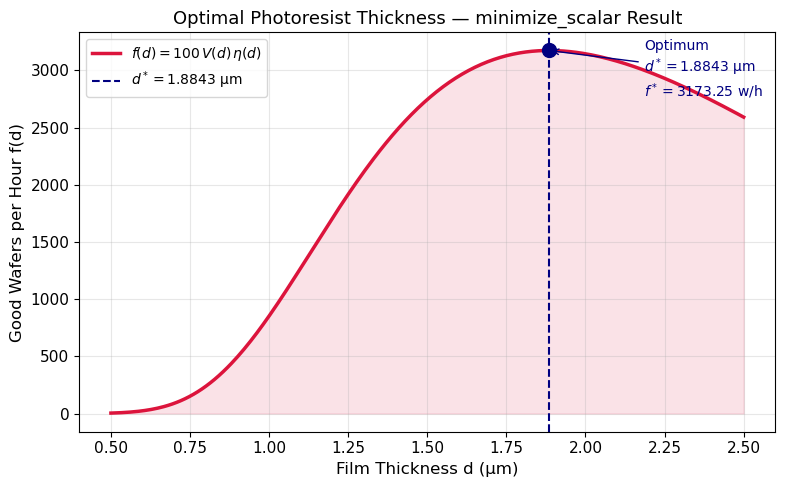

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs\fig_02_minimize_scalar_result.png


In [5]:
# ========================================
# 使用 minimize_scalar 求解最佳膜厚
# ========================================
result = minimize_scalar(
    fun=lambda d: objective(d, beta=BETA, a=A),
    method='bounded',
    bounds=(0.5, 2.5)
)

d_opt_scipy = result.x
f_opt_scipy = -result.fun   # 還原為最大化值（取負號）

print("=" * 50)
print("  minimize_scalar (Brent's Method) 求解結果")
print("=" * 50)
print(f"  收斂狀態  : {'成功 ✓' if result.success else '失敗 ✗'}")
print(f"  函數評估次: {result.nfev}")
print(f"  最佳膜厚 d*  = {d_opt_scipy:.6f} μm")
print(f"  最大產量 f*  = {f_opt_scipy:.4f} wafers/h")
print(f"    ├ 缺損密度 D0 = {defect_density(d_opt_scipy):.4f}")
print(f"    ├ 良率    η   = {yield_fraction(d_opt_scipy)*100:.2f} %")
print(f"    └ 產量    V   = {throughput(d_opt_scipy):.2f} wafers/h")
print("=" * 50)

# ========================================
# 繪製目標函數與最佳點
# ========================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_range, f_vals, color='crimson', linewidth=2.5, label='$f(d) = 100\\,V(d)\\,\\eta(d)$')
ax.axvline(d_opt_scipy, color='navy', linestyle='--', linewidth=1.5, label=f'$d^* = {d_opt_scipy:.4f}$ μm')
ax.scatter([d_opt_scipy], [f_opt_scipy], color='navy', s=100, zorder=5)
ax.annotate(
    f'Optimum\n$d^*={d_opt_scipy:.4f}$ μm\n$f^*={f_opt_scipy:.2f}$ w/h',
    xy=(d_opt_scipy, f_opt_scipy),
    xytext=(d_opt_scipy + 0.3, f_opt_scipy - 400),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='navy'),
    color='navy'
)
ax.fill_between(d_range, f_vals, alpha=0.12, color='crimson')
ax.set_xlabel('Film Thickness d (μm)')
ax.set_ylabel('Good Wafers per Hour f(d)')
ax.set_title('Optimal Photoresist Thickness — minimize_scalar Result')
ax.legend()
plt.tight_layout()
fig_path = FIG_DIR / 'fig_02_minimize_scalar_result.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔已儲存：{fig_path}")

---
### 5. 黃金分割法（Golden Section Search）實作與比較

以 Python 手動實作黃金分割法，與 `minimize_scalar` 結果比較，驗證兩方法一致性。

**演算法核心：** 黃金比例 $\phi = (\sqrt{5}-1)/2 \approx 0.6180$，每次迭代縮小約 38.2% 的搜尋區間，僅需一次新的函數評估（另一點重用前次計算結果）。

In [6]:
# ========================================
# 黃金分割法實作
# ========================================
def golden_section_search(func, a, b, tol=1e-8, max_iter=1000):
    """
    黃金分割法求單變數函數的最小值。

    Parameters
    ----------
    func     : 目標函數（最小化方向）
    a, b     : 搜尋區間下限與上限
    tol      : 收斂容差（區間長度 < tol 時停止）
    max_iter : 最大迭代次數

    Returns
    -------
    x_opt  : 最佳解
    f_opt  : 最小目標函數值
    niter  : 實際迭代次數
    nfev   : 函數評估次數
    """
    phi = (np.sqrt(5) - 1) / 2   # 黃金比例 ≈ 0.6180

    c = b - phi * (b - a)
    d_pt = a + phi * (b - a)
    fc = func(c)
    fd = func(d_pt)
    nfev = 2    # 初始兩次評估

    for niter in range(1, max_iter + 1):
        if fc < fd:
            b = d_pt
            d_pt, fd = c, fc
            c = b - phi * (b - a)
            fc = func(c)
            nfev += 1
        else:
            a = c
            c, fc = d_pt, fd
            d_pt = a + phi * (b - a)
            fd = func(d_pt)
            nfev += 1

        if abs(b - a) < tol:
            break

    x_opt = (a + b) / 2
    f_opt = func(x_opt)
    nfev += 1
    return x_opt, f_opt, niter, nfev

# ========================================
# 執行黃金分割法求解
# ========================================
d_opt_gs, neg_f_opt_gs, n_iter_gs, n_fev_gs = golden_section_search(
    func=lambda d: objective(d, beta=BETA, a=A),
    a=0.5, b=2.5, tol=1e-8
)
f_opt_gs = -neg_f_opt_gs   # 還原最大化值

print("=" * 50)
print("  黃金分割法（Golden Section Search）求解結果")
print("=" * 50)
print(f"  迭代次數   : {n_iter_gs}")
print(f"  函數評估次 : {n_fev_gs}")
print(f"  最佳膜厚 d*  = {d_opt_gs:.6f} μm")
print(f"  最大產量 f*  = {f_opt_gs:.4f} wafers/h")
print("=" * 50)

# ========================================
# 結果比較
# ========================================
print("\n  ── 方法比較 ──")
print(f"{'':>4}{'方法':<28} {'d* (μm)':>12} {'f* (w/h)':>12} {'nfev':>6}")
print(f"  {'minimize_scalar (Brent)':<28} {d_opt_scipy:>12.6f} {f_opt_scipy:>12.4f} {result.nfev:>6}")
print(f"  {'Golden Section Search':<28} {d_opt_gs:>12.6f} {f_opt_gs:>12.4f} {n_fev_gs:>6}")
print(f"\n  差異 |Δd*| = {abs(d_opt_scipy - d_opt_gs):.2e} μm")
print(f"  差異 |Δf*| = {abs(f_opt_scipy - f_opt_gs):.2e} wafers/h")

  黃金分割法（Golden Section Search）求解結果
  迭代次數   : 40
  函數評估次 : 43
  最佳膜厚 d*  = 1.884324 μm
  最大產量 f*  = 3173.2456 wafers/h

  ── 方法比較 ──
    方法                                d* (μm)     f* (w/h)   nfev
  minimize_scalar (Brent)          1.884325    3173.2456     10
  Golden Section Search            1.884324    3173.2456     43

  差異 |Δd*| = 8.72e-07 μm
  差異 |Δf*| = 1.78e-09 wafers/h


---
### 6. 黃金分割法收斂過程視覺化

繪製黃金分割法每次迭代的搜尋區間縮小過程與目標函數值的收斂曲線。

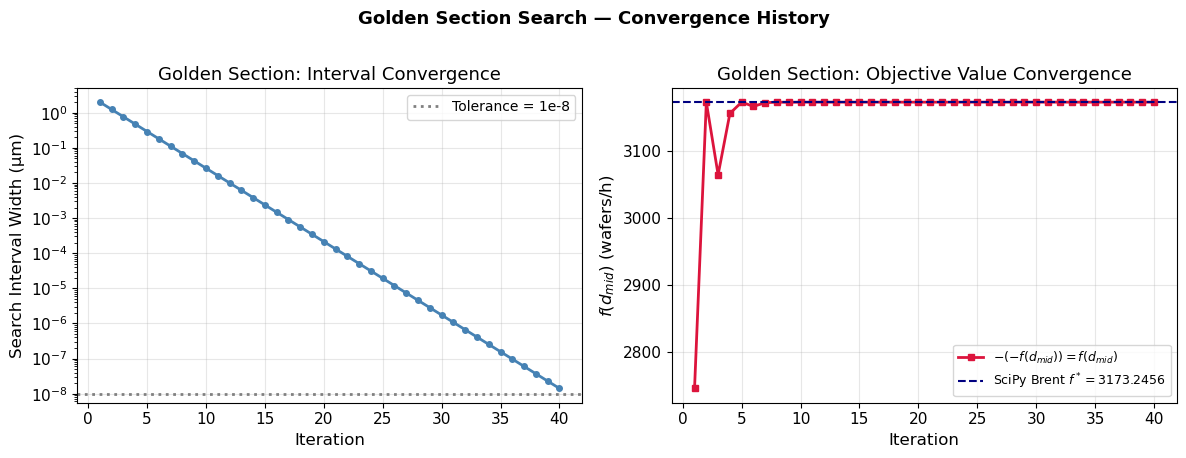

  迭代次數: 40
✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs\fig_03_golden_section_convergence.png


In [7]:
# ========================================
# 追蹤黃金分割法迭代過程（帶記錄功能版本）
# ========================================
def golden_section_search_tracked(func, a0, b0, tol=1e-8, max_iter=1000):
    """帶追蹤記錄的黃金分割法"""
    phi = (np.sqrt(5) - 1) / 2
    a, b = a0, b0

    c = b - phi * (b - a)
    dp = a + phi * (b - a)
    fc, fd_val = func(c), func(dp)

    history = {'iter': [], 'a': [], 'b': [], 'mid': [], 'f_mid': [], 'width': []}

    for niter in range(1, max_iter + 1):
        mid = (a + b) / 2
        history['iter'].append(niter)
        history['a'].append(a)
        history['b'].append(b)
        history['mid'].append(mid)
        history['f_mid'].append(func(mid))
        history['width'].append(b - a)

        if fc < fd_val:
            b = dp
            dp, fd_val = c, fc
            c = b - phi * (b - a)
            fc = func(c)
        else:
            a = c
            c, fc = dp, fd_val
            dp = a + phi * (b - a)
            fd_val = func(dp)

        if abs(b - a) < tol:
            break

    return (a + b) / 2, history

d_gs2, gs_hist = golden_section_search_tracked(
    lambda d: objective(d, beta=BETA, a=A),
    a0=0.5, b0=2.5, tol=1e-8
)

iters   = np.array(gs_hist['iter'])
f_mids  = np.array(gs_hist['f_mid'])   # 這裡是 -f(mid) 值
widths  = np.array(gs_hist['width'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 子圖 1: 搜尋區間寬度收斂
ax = axes[0]
ax.semilogy(iters, widths, 'o-', color='steelblue', markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Search Interval Width (μm)')
ax.set_title('Golden Section: Interval Convergence')
ax.axhline(1e-8, color='gray', linestyle=':', label='Tolerance = 1e-8')
ax.legend()

# 子圖 2: 目標函數值收斂
ax = axes[1]
ax.plot(iters, -f_mids, 's-', color='crimson', markersize=4, label='$-(-f(d_{mid})) = f(d_{mid})$')
ax.axhline(f_opt_scipy, color='navy', linestyle='--', linewidth=1.5, label=f'SciPy Brent $f^*={f_opt_scipy:.4f}$')
ax.set_xlabel('Iteration')
ax.set_ylabel('$f(d_{mid})$ (wafers/h)')
ax.set_title('Golden Section: Objective Value Convergence')
ax.legend(fontsize=9)

plt.suptitle('Golden Section Search — Convergence History', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / 'fig_03_golden_section_convergence.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"  迭代次數: {len(iters)}")
print(f"✓ 圖檔已儲存：{fig_path}")

---
### 7. 敏感度分析（Sensitivity Analysis）

探討製程參數 $\beta$（工藝因子）和 $a$（晶片面積）的變化對最佳膜厚 $d^*$ 與最大產量 $f^*$ 的影響。此分析有助於了解最適解對製程不確定性的強健性。

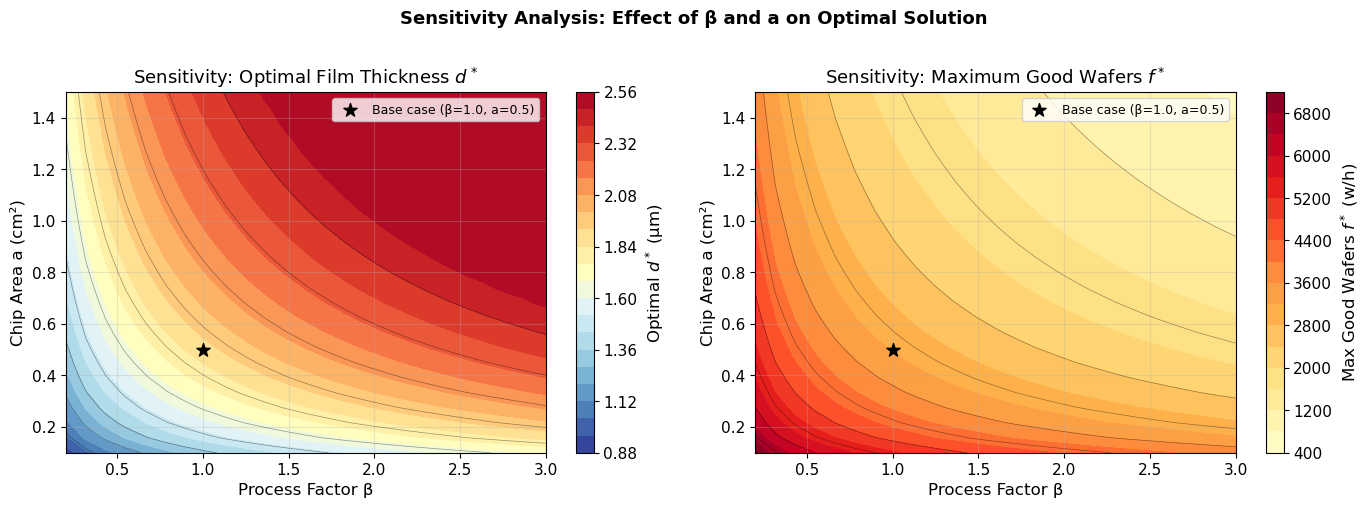

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs\fig_04_sensitivity_heatmap.png


In [8]:
# ========================================
# 敏感度分析：beta 與 a 參數網格掃描
# ========================================
beta_vals = np.linspace(0.2, 3.0, 25)   # 工藝因子範圍
a_vals    = np.linspace(0.1, 1.5, 25)   # 晶片面積範圍 (cm²)

d_opt_grid = np.zeros((len(a_vals), len(beta_vals)))
f_opt_grid = np.zeros((len(a_vals), len(beta_vals)))

for i, a_v in enumerate(a_vals):
    for j, beta_v in enumerate(beta_vals):
        res = minimize_scalar(
            lambda d: objective(d, beta=beta_v, a=a_v),
            method='bounded', bounds=(0.5, 2.5)
        )
        d_opt_grid[i, j] = res.x
        f_opt_grid[i, j] = -res.fun

# ========================================
# 熱圖視覺化
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].contourf(beta_vals, a_vals, d_opt_grid, levels=20, cmap='RdYlBu_r')
fig.colorbar(im0, ax=axes[0], label='Optimal $d^*$ (μm)')
axes[0].set_xlabel('Process Factor β')
axes[0].set_ylabel('Chip Area a (cm²)')
axes[0].set_title('Sensitivity: Optimal Film Thickness $d^*$')
# 標示基準點
axes[0].scatter([BETA], [A], color='black', s=100, marker='*', zorder=5, label='Base case (β=1.0, a=0.5)')
axes[0].legend(fontsize=9)
axes[0].contour(beta_vals, a_vals, d_opt_grid, levels=10, colors='k', linewidths=0.5, alpha=0.4)

im1 = axes[1].contourf(beta_vals, a_vals, f_opt_grid, levels=20, cmap='YlOrRd')
fig.colorbar(im1, ax=axes[1], label='Max Good Wafers $f^*$ (w/h)')
axes[1].set_xlabel('Process Factor β')
axes[1].set_ylabel('Chip Area a (cm²)')
axes[1].set_title('Sensitivity: Maximum Good Wafers $f^*$')
axes[1].scatter([BETA], [A], color='black', s=100, marker='*', zorder=5, label='Base case (β=1.0, a=0.5)')
axes[1].legend(fontsize=9)
axes[1].contour(beta_vals, a_vals, f_opt_grid, levels=10, colors='k', linewidths=0.5, alpha=0.4)

plt.suptitle('Sensitivity Analysis: Effect of β and a on Optimal Solution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / 'fig_04_sensitivity_heatmap.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔已儲存：{fig_path}")

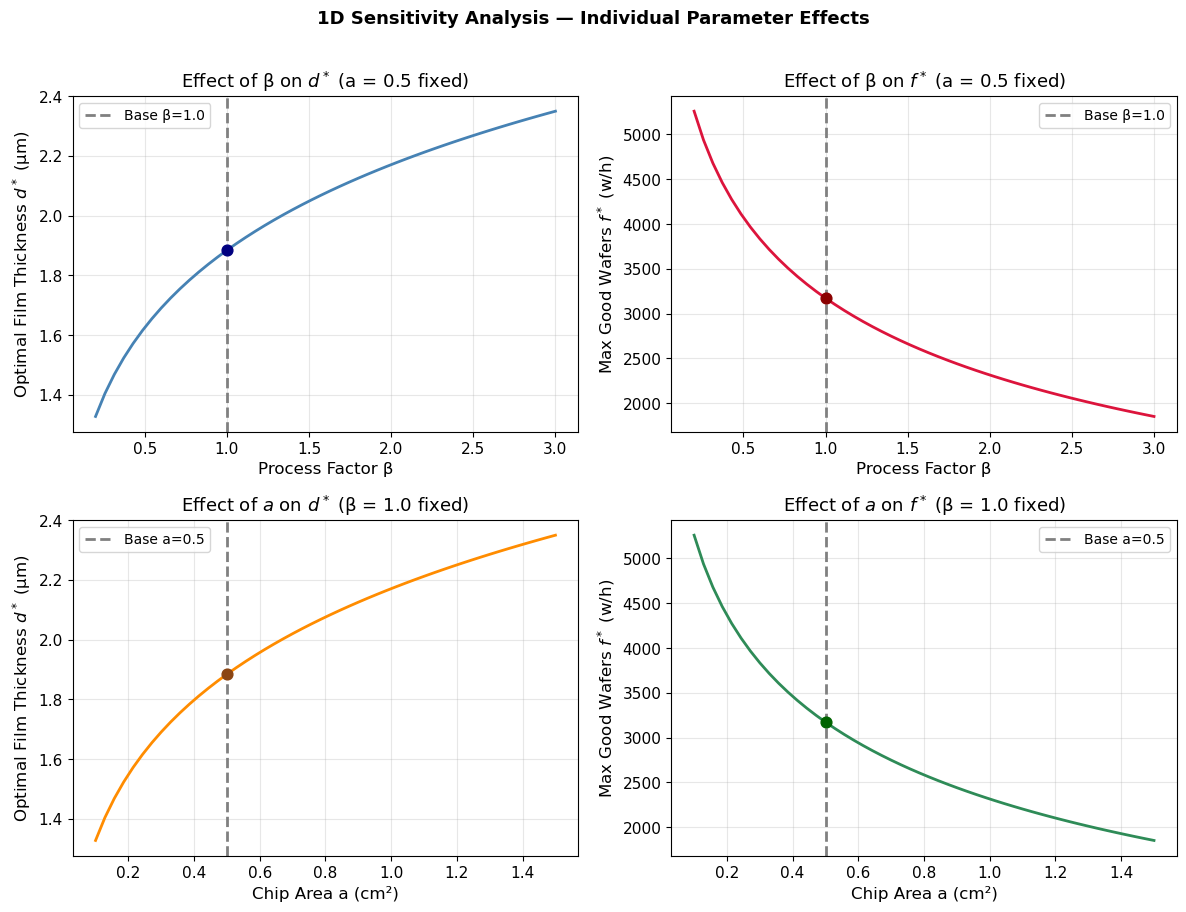

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_01\figs\fig_05_sensitivity_1d.png


In [9]:
# ========================================
# 一維敏感度曲線（固定一個參數，掃描另一個）
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ─── 掃描 beta（固定 a = A）───
beta_scan = np.linspace(0.2, 3.0, 50)
d_opt_beta = []
f_opt_beta = []
for beta_v in beta_scan:
    res = minimize_scalar(lambda d: objective(d, beta=beta_v, a=A), method='bounded', bounds=(0.5, 2.5))
    d_opt_beta.append(res.x)
    f_opt_beta.append(-res.fun)

ax = axes[0, 0]
ax.plot(beta_scan, d_opt_beta, color='steelblue', linewidth=2)
ax.axvline(BETA, color='gray', linestyle='--', label=f'Base β={BETA}')
ax.scatter([BETA], [d_opt_scipy], color='navy', s=60, zorder=5)
ax.set_xlabel('Process Factor β')
ax.set_ylabel('Optimal Film Thickness $d^*$ (μm)')
ax.set_title('Effect of β on $d^*$ (a = 0.5 fixed)')
ax.legend()

ax = axes[0, 1]
ax.plot(beta_scan, f_opt_beta, color='crimson', linewidth=2)
ax.axvline(BETA, color='gray', linestyle='--', label=f'Base β={BETA}')
ax.scatter([BETA], [f_opt_scipy], color='darkred', s=60, zorder=5)
ax.set_xlabel('Process Factor β')
ax.set_ylabel('Max Good Wafers $f^*$ (w/h)')
ax.set_title('Effect of β on $f^*$ (a = 0.5 fixed)')
ax.legend()

# ─── 掃描 a（固定 beta = BETA）───
a_scan = np.linspace(0.1, 1.5, 50)
d_opt_a = []
f_opt_a = []
for a_v in a_scan:
    res = minimize_scalar(lambda d: objective(d, beta=BETA, a=a_v), method='bounded', bounds=(0.5, 2.5))
    d_opt_a.append(res.x)
    f_opt_a.append(-res.fun)

ax = axes[1, 0]
ax.plot(a_scan, d_opt_a, color='darkorange', linewidth=2)
ax.axvline(A, color='gray', linestyle='--', label=f'Base a={A}')
ax.scatter([A], [d_opt_scipy], color='saddlebrown', s=60, zorder=5)
ax.set_xlabel('Chip Area a (cm²)')
ax.set_ylabel('Optimal Film Thickness $d^*$ (μm)')
ax.set_title('Effect of $a$ on $d^*$ (β = 1.0 fixed)')
ax.legend()

ax = axes[1, 1]
ax.plot(a_scan, f_opt_a, color='seagreen', linewidth=2)
ax.axvline(A, color='gray', linestyle='--', label=f'Base a={A}')
ax.scatter([A], [f_opt_scipy], color='darkgreen', s=60, zorder=5)
ax.set_xlabel('Chip Area a (cm²)')
ax.set_ylabel('Max Good Wafers $f^*$ (w/h)')
ax.set_title('Effect of $a$ on $f^*$ (β = 1.0 fixed)')
ax.legend()

plt.suptitle('1D Sensitivity Analysis — Individual Parameter Effects',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / 'fig_05_sensitivity_1d.png'
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔已儲存：{fig_path}")

---
### 8. 重點整理

| 項目 | 說明 |
|------|------|
| 問題類型 | 單變數有界最適化：$\min_{0.5 \leq d \leq 2.5} [-f(d)]$ |
| SciPy 函式 | `minimize_scalar(method='bounded', bounds=(0.5, 2.5))` |
| 演算法 | Brent's Method（黃金分割 + 拋物線插值）|
| 手動方法 | Golden Section Search（無導數，區間縮小法）|
| 最大化轉換 | $\max f(d)\ \Leftrightarrow\ \min [-f(d)]$ |
| 敏感度分析 | $\beta \uparrow$ 或 $a \uparrow$ → 缺損影響加劇 → $d^*$ 增大，$f^*$ 下降 |

**學習要點：**
- `minimize_scalar` 是 SciPy 求解單變數有界最適化問題的標準工具
- Brent 法兼具黃金分割的穩定性與拋物線插值的效率，是實務上的首選
- 黃金分割法原理簡單，適合教學演示最優搜尋策略的核心思想
- 敏感度分析是工程設計中評估製程參數不確定性的重要手段

---

>
> **課程資訊：** 逢甲大學 化工系 電腦在化工上之應用 (ChemE 3502) — Unit12 程序最適化 範例 01
>
> **課程授權 [CC BY-NC-SA 4.0]**：本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。